#  Kernel PCA
Non-Linear Dimensionality reduction through the use of kernels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
sns.set()

In [6]:
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA,KernelPCA

In [7]:
np.random.seed(0)
X,y=make_circles(n_samples=400,factor=.3,noise=.05)

In [8]:
kpca=KernelPCA(kernel='rbf',fit_inverse_transform=True,gamma=10)
X_kpca=kpca.fit_transform(X)
X_back=kpca.inverse_transform(X_kpca)

pca=PCA()
X_pca=pca.fit_transform(X)

## Normal plot

Text(0, 0.5, '$x_2$')

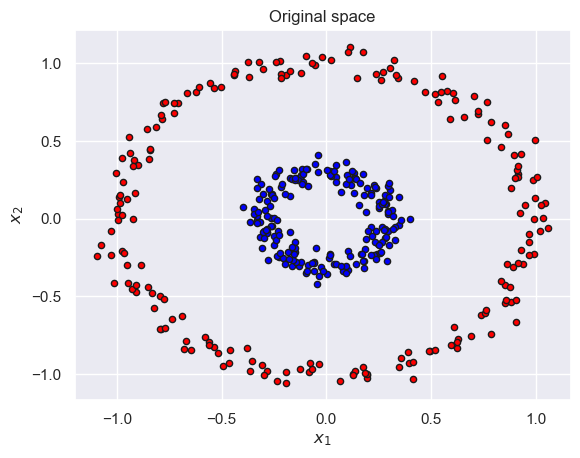

In [9]:
plt.figure()
plt.title('Original space')
reds=y==0
blues=y==1

plt.scatter(X[reds,0],X[reds,1],c='red',s=20,edgecolor='k')
plt.scatter(X[blues,0],X[blues,1],c='blue',s=20,edgecolor='k')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

The above figure is before Transforming.(i.e before apllying Linear PCA)

## PCA Plot

Text(0, 0.5, '2nd Component')

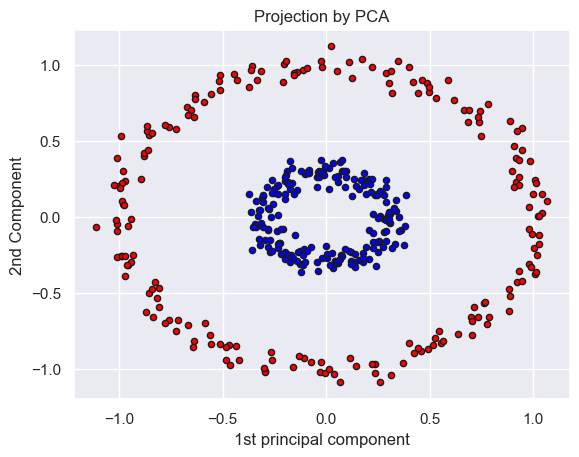

In [10]:
plt.scatter(X_pca[reds,0],X_pca[reds,1],c='red',s=20,edgecolor='k')
plt.scatter(X_pca[blues,0],X_pca[blues,1],c='blue',s=20,edgecolor='k')
plt.title('Projection by PCA')
plt.xlabel('1st principal component')
plt.ylabel('2nd Component')

The linear pca Transformed figure has very slight variations comapered to before transforming figure.  
Because Non Linear transforming is required.

# KPCA plot

Text(0, 0.5, '2nd Component')

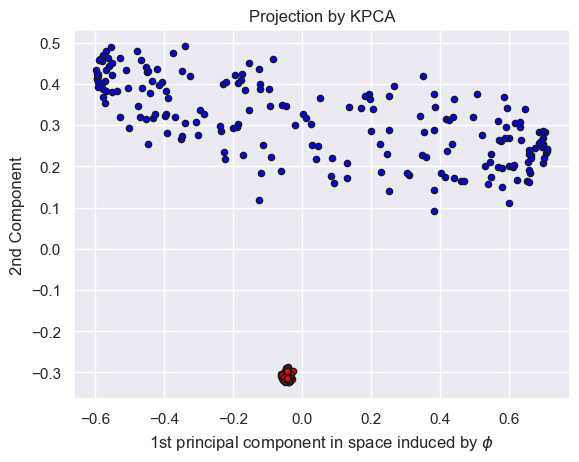

In [11]:
plt.scatter(X_kpca[reds,0],X_kpca[reds,1],c='red',s=20,edgecolor='k')
plt.scatter(X_kpca[blues,0],X_kpca[blues,1],c='blue',s=20,edgecolor='k')
plt.title('Projection by KPCA')
plt.xlabel('1st principal component in space induced by $\phi$')
plt.ylabel('2nd Component')

We can see the seperation between the blue and red. It is due to KernelPCA

## KernelPCA Example

In [12]:
df=sns.load_dataset('iris')
df=df[df['species']!='setosa']

In [14]:
col=['petal_length','petal_width']
X=df.loc[:,col]
species_to_num={'versicolor':0,
                'virginica':1}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']

In [15]:
kpca=KernelPCA(kernel='rbf',n_components=2)
X_kpca=kpca.fit_transform(X)

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
clf=LogisticRegression(solver='lbfgs')
clf.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
Xv=X.values.reshape(-1,1)
h=0.02
x_min,x_max=Xv.min(),Xv.max()+1
y_min,y_max=y.min(),y.max()+2
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))


C:\Users\ADMIN\anaconda3\envs\ML_Python\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


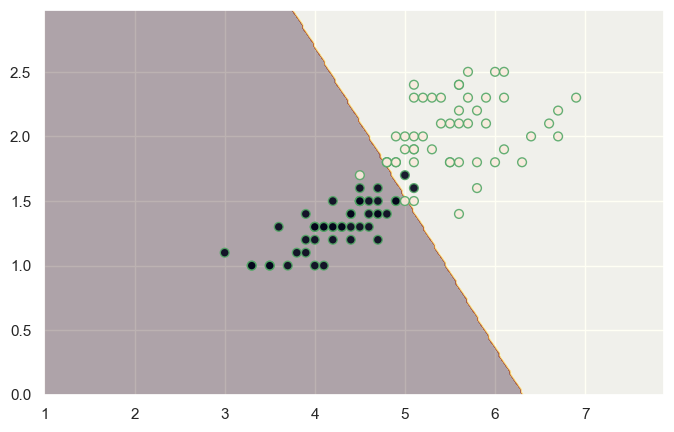

In [21]:
z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)

fig=plt.figure(figsize=(8,5))
ax=plt.contourf(xx,yy,z,cmap='afmhot',alpha=0.3)
plt.scatter(X.values[:,0],X.values[:,1],c=y,s=40,
            alpha=0.9,edgecolor='g')

In [22]:
clf.fit(X_kpca,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
Xv=X_kpca
h=0.02
x_min,x_max=Xv.min()-0.5,Xv.max()+0.5
y_min,y_max=y.min()-0.5,y.max()
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))


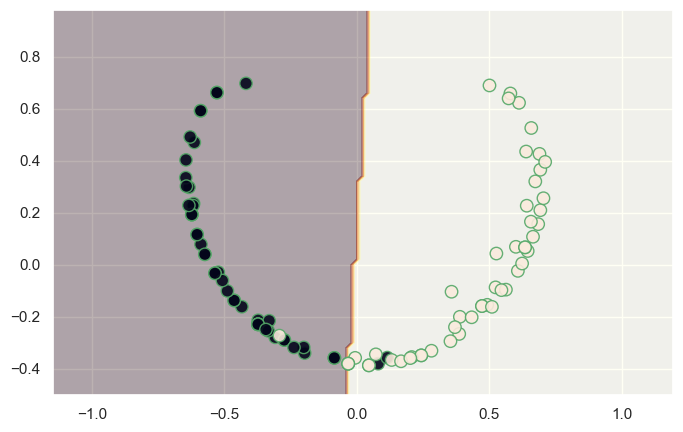

In [26]:
z=clf.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)

fig=plt.figure(figsize=(8,5))
ax=plt.contourf(xx,yy,z,cmap='afmhot',alpha=0.3)
plt.scatter(X_kpca[:,0],X_kpca[:,1],c=y,s=80,
            alpha=0.9,edgecolor='g')